In [7]:
from dataMaker import DataHandler
import plotter
import dataLoader

import torch
from torch.utils import data
import matplotlib.pyplot as plt
import numpy as np

### Data Paths

In [8]:
data_dir = '/workspace/data/cv_project'

train_data = data_dir + '/grid_data_atten_big_train.h5'
val_data = data_dir + '/grid_data_atten_big_val.h5'
test_data = data_dir + '/grid_data_atten_big_test.h5'
mat_data = data_dir + '/grid_data_atten.mat'
mat_noise = data_dir + '/noise_only_data_atten.mat'

### Generate Spectrogams

Here we generate spectrograms from the .mat files which contain the results of the [KRAKEN](https://oalib-acoustics.org/models-and-software/normal-modes/) simulation.

In [3]:
# Load simulated data into data object
handler = DataHandler(path=mat_data, noise_only_path=mat_noise)

# Make each audio waveform have mean=0 and var=1
handler.normalize_wav()

# Create spectrograms
handler.create_spectrograms(rand_shift=True, nperseg=60, noverlap=52, nfft=750, verbose=True)

# Save data
handler.save_split_h5(train_path=train_data, 
                      val_path=val_data, 
                      test_path=test_data, 
                      train_size=0.8, 
                      test_size=0.1, 
                      val_size=0.1, 
                      shuffle=True)

del handler

  0%|          | 0/40336 [00:00<?, ?it/s]

### Visualize Data

Load the validation data.

In [5]:
X, y = dataLoader.load_h5(val_data)
X_20k = X[y[:,0] == 30000,...]
y_20k = y[y[:,0] == 30000]

In [6]:
X.shape

(4034, 3, 224, 224)

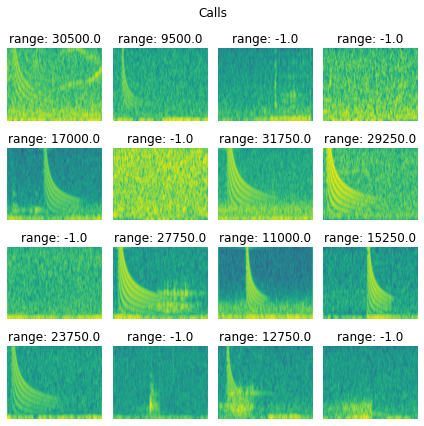

In [8]:
c = 0
plotter.plot_grid(X[:,[c],:,:], y[:,0].squeeze(), label_text="range", title="Calls", dim=(4,4))

Plot the different classes

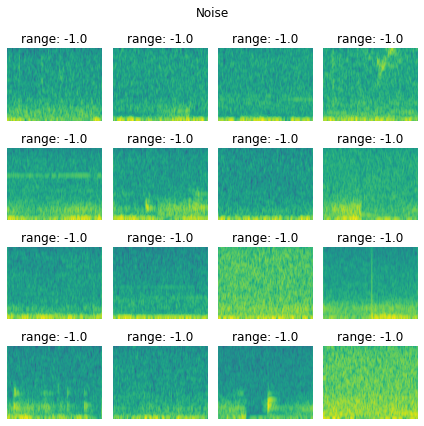

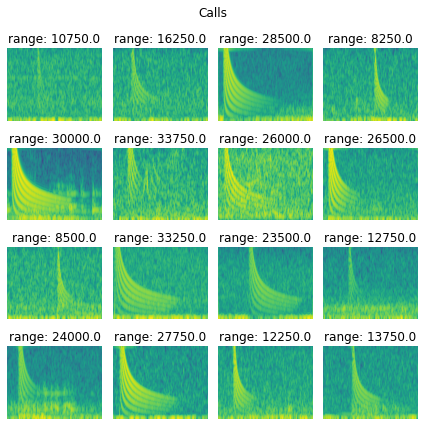

In [9]:
c = 0
X_c = X[:,[c],:,:]

# Plot examples from noise class
plotter.plot_grid(X_c[np.where(y[:,4] == 0)], y[np.where(y[:,4] == 0),0].squeeze(), label_text="range", title="Noise", dim=(4,4))

# Plot examples from call class
plotter.plot_grid(X_c[np.where(y[:,4] == 1)], y[np.where(y[:,4] == 1),0].squeeze(), label_text="range", title="Calls", dim=(4,4))

### Get Training Set Statistics

In [9]:
# Create dataset and dataloader
dataset = dataLoader.Gunshot(dir_path=train_data, max_range=35000)
dataloader = data.DataLoader(dataset, batch_size=32, drop_last=False, shuffle=True)

In [10]:
next(iter(dataloader))[0].shape

torch.Size([32, 3, 224, 224])

In [10]:
from tqdm.notebook import tqdm

# Placeholders
psum = torch.tensor([0.0, 0.0, 0.0])
psum_sq = torch.tensor([0.0, 0.0, 0.0])

# Calculate sum of data and sum of squared data
for inputs, _, _ in tqdm(dataloader):
    psum += inputs.sum(axis=(0,2,3))
    psum_sq += (inputs ** 2).sum(axis=(0,2,3))

# Calculate mean and std via:
# var = E[X^2] - E[X]^2
# std = sqrt(var)
count = len(dataset)*dataset.imsize[0]*dataset.imsize[1]
total_mean = psum / count
total_var = (psum_sq / count) - (total_mean ** 2)
total_std = torch.sqrt(total_var)

print('mean: ', total_mean)
print('std: ', total_std)

  0%|          | 0/807 [00:00<?, ?it/s]

mean:  tensor([0.4819, 0.5533, 0.5538])
std:  tensor([0.1523, 0.1370, 0.1381])
